In [1]:
import inspect

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Original V2_01_Easy Dataset with NO Modifications @6Hz

In [2]:
base_dir = '/home/shiva/Datasets/V2_01_easy/V2_01_easy/Kimera_VIO_Output'
working_dir = '5_Runs_New_Kimera_V2_01_Easy_4Hz_Frame/'

execution_folder_names = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']

In [3]:
dfs = []

for index, execution_folder_name in enumerate(execution_folder_names):
    df = pd.read_csv(f'{base_dir}/{working_dir}/{execution_folder_name}/traj_vio.csv')
    df['Execution_No'] = index
    df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)
    dfs.append(df)

In [4]:
gt_df = pd.read_csv(f'{base_dir}/{working_dir}/{execution_folder_names[0]}/traj_gt.csv')
gt_df['Execution_No'] = 'GT'
gt_df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)
dfs.append(gt_df)

In [5]:
gt_df.shape

(22401, 18)

In [6]:
all_executions = pd.concat(dfs)

In [7]:
all_executions

,timestamp,x,y,z,qw,qx,qy,qz,vx,vy,vz,bgx,bgy,bgz,bax,bay,baz,Execution_No
0,1413393214805760512,-1.079201,0.491987,1.329317,0.606023,-0.006431,-0.795364,0.009480,0.004087,-0.000583,0.000541,-0.002295,0.024939,0.081667,-0.023600,0.121043,0.074792,0
1,1413393215005760512,-1.078746,0.491833,1.329873,0.605930,-0.006542,-0.795432,0.009472,0.000318,0.000078,0.006343,-0.002325,0.024899,0.081699,-0.011453,0.120780,0.070724,0
2,1413393215455760384,-1.078462,0.491920,1.330019,0.605463,-0.006460,-0.795787,0.009487,0.000254,0.003245,0.001415,-0.002236,0.023740,0.082405,0.000960,0.120495,0.067183,0
3,1413393215655760384,-1.078651,0.492080,1.329862,0.605074,-0.006776,-0.796077,0.009643,0.000219,0.003614,0.000427,-0.002067,0.023709,0.082525,0.001155,0.120924,0.067077,0
4,1413393215855760384,-1.077449,0.492604,1.330289,0.603278,-0.006623,-0.797439,0.009601,0.008526,0.003663,0.006159,-0.002247,0.023448,0.082881,-0.016537,0.118312,0.067614,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22396,1413393325460760576,-2.908236,-0.450484,0.954966,0.470117,-0.487871,-0.641203,-0.360319,-0.004458,-0.000779,0.002868,-0.002275,0.024883,0.081577,-0.019635,0.123542,0.078490,GT
22397,1413393325465760512,-2.908261,-0.450489,0.954981,0.470124,-0.487874,-0.641195,-0.360321,-0.005729,-0.000886,0.003278,-0.002275,0.024883,0.081577,-0.019635,0.123542,0.078490,GT
22398,1413393325470760704,-2.908291,-0.450493,0.954999,0.470141,-0.487865,-0.641193,-0.360314,-0.005961,-0.000836,0.003708,-0.002275,0.024883,0.081577,-0.019635,0.123542,0.078490,GT
22399,1413393325475760384,-2.908319,-0.450497,0.955018,0.470158,-0.487853,-0.641195,-0.360304,-0.005469,-0.000641,0.004049,-0.002275,0.024883,0.081577,-0.019635,0.123542,0.078490,GT


In [8]:
sns.set_theme(rc={'figure.figsize':(12,6)})

[(-4.0, 4.0)]

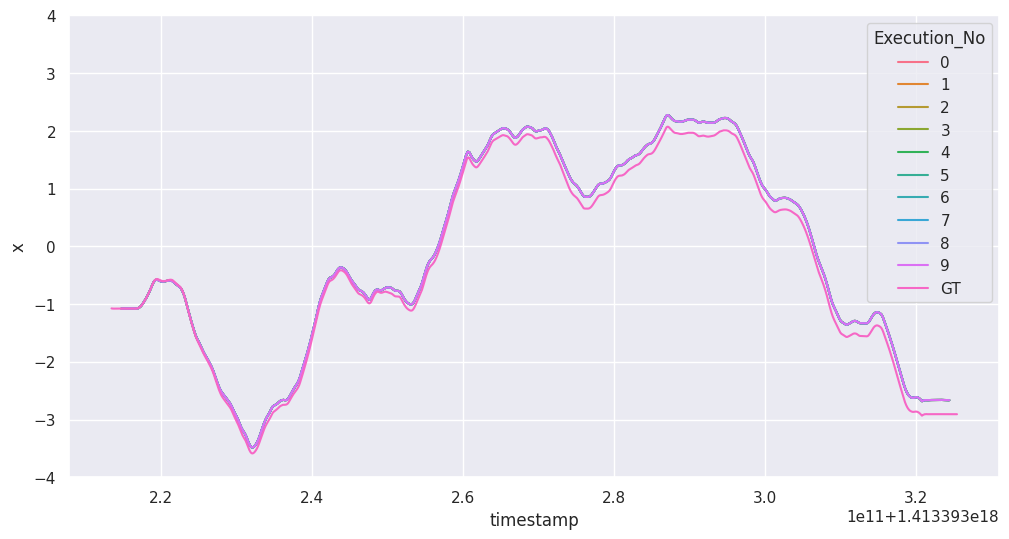

In [9]:

ax = sns.lineplot(data=all_executions, x='timestamp', y='x', hue='Execution_No')
ax.set(ylim=(-4, 4))

[(-4.0, 4.0)]

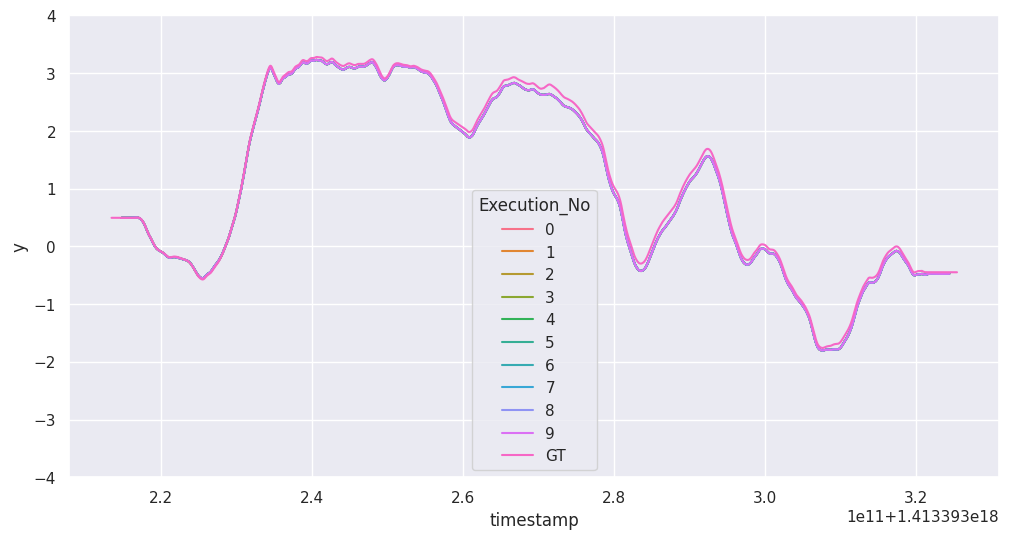

In [10]:
ax = sns.lineplot(data=all_executions, x='timestamp', y='y', hue='Execution_No')
ax.set(ylim=(-4, 4))

[(-4.0, 4.0)]

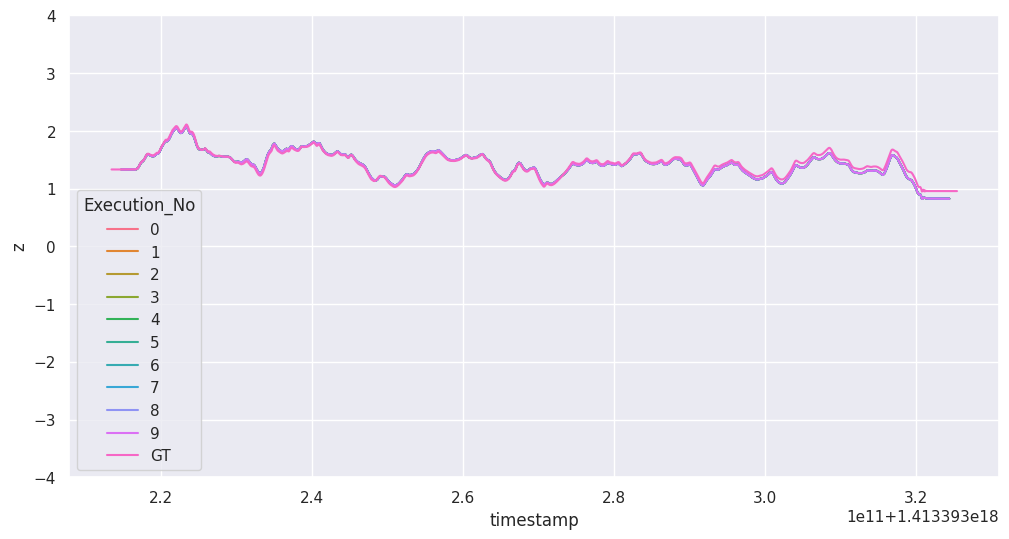

In [11]:
ax = sns.lineplot(data=all_executions, x='timestamp', y='z', hue='Execution_No')
ax.set(ylim=(-4, 4))

In [12]:
dfs[0].shape

(541, 18)

In [12]:
# https://github.com/Virtana/indoor_drone_experimentation/blob/main/kimera_remote_eval/drift_assessment.py
def euclidean_dist(val1, val2) -> int:
    """
    val1 - [x,y,z] array for one point
    val2 - [x,y,z] array for other point
    """
    distance = np.linalg.norm(np.array(val1)-np.array(val2))
    return distance

def match_gt_vio_ts(gt_df, vio_df, start_gt_index, vio_index, DEBUG=False) -> int:
    # ------------------------------------------------------------------------
    # Getting the corresponding gt_ts/index for the next iteration of the loop
    # ------------------------------------------------------------------------
    # Initialise min_ts_diff to something arbitrarily large
    min_ts_diff = 1000000000000000000
    # Get corresponding vio_ts
    # print(vio_index)
    vio_ts = vio_df.iloc[vio_index]['timestamp']
    
    # We increment the ground truth index until we find the smallest difference between the
    # vio ts and the gt ts
    next_gt_ind = start_gt_index + 1
    ts_diff = abs(vio_ts - gt_df['timestamp'].iloc[next_gt_ind])
    min_ts_index = 0

    #     Rationale: We will always start from a ts earlier than the vio ts.
    #     As we move towards it, the value will become smaller. A value after our
    #     ts that is smaller will still be closer. As we move later into the future,
    #     the difference will increase again. 
    #     When the diff is 0, this still holds.
    num_gt_indices = len(gt_df.index)-1
    while ts_diff < min_ts_diff and next_gt_ind < num_gt_indices:
        min_ts_diff = ts_diff 
        min_ts_index = next_gt_ind

        # Updating ts_diff for the next iteration
        next_gt_ind += 1
        ts_diff = abs(vio_ts - gt_df['timestamp'].iloc[next_gt_ind])

    if DEBUG:
        print(f"Min ts_diff: {min_ts_diff}")
    return min_ts_index # Updating curr_gt_index for the next iteration

def generate_error_gt_vio_pose(gt_df, vio_df, DEBUG=False, SHOW_GRAPHS=False):
    # -----------------------------------------------------------------
    # Comparing x, y and z state estimates to ground truth over time.
    # -----------------------------------------------------------------
    # Generating time passed using timestamp data
    # For ground truth
    gt_time_passed = []
    total_time = 0
    for i in range(len(gt_df)):
        if i == 0:
            gt_time_passed.append(0)
        else:
            time_diff_ms = (gt_df['timestamp'].iloc[i] - gt_df['timestamp'].iloc[i-1])/1000000
            total_time += time_diff_ms
            gt_time_passed.append(total_time)    
    
    gt_time_ms_df = pd.DataFrame(gt_time_passed, columns=['time_ms'])
    
    # For VIO state estimate
    # Finding the offset between ground truth and vio estimates
    gt_vio_start_diff = (vio_df['timestamp'].iloc[0] - gt_df['timestamp'].iloc[0])/1000000
    
    vio_time_passed = []
    total_time = gt_vio_start_diff
    for i in range(len(vio_df)):
        if i == 0:
            vio_time_passed.append(0)
        else:
            time_diff_ms = (vio_df['timestamp'].iloc[i] - vio_df['timestamp'].iloc[i-1])/1000000
            total_time += time_diff_ms
            vio_time_passed.append(total_time)
    vio_time_ms_df = pd.DataFrame(vio_time_passed, columns=['time_ms'])

    if SHOW_GRAPHS:
        plt.figure()
        plt.subplot(3, 1, 1)
        plt.plot(gt_time_ms_df["time_ms"], gt_df["x"])
        plt.plot(vio_time_ms_df["time_ms"], vio_df["x"])
        plt.legend(["gt", "vio"])
        plt.xlabel("time/ms")
        plt.ylabel("x position/m")
        plt.title("x over time")
        plt.grid(True, which='both', linestyle='--')
        plt.minorticks_on()
        
        plt.subplot(3, 1, 2)
        plt.plot(gt_time_ms_df["time_ms"], gt_df["y"])
        plt.plot(vio_time_ms_df["time_ms"], vio_df["y"])
        plt.title("y over time")
        plt.xlabel("time/ms")
        plt.ylabel("y position/m")
        plt.legend(["gt", "vio"])
        plt.grid(True, which='both', linestyle='--')
        plt.minorticks_on()
        
        plt.subplot(3, 1, 3)
        plt.plot(gt_time_ms_df["time_ms"], gt_df["z"])
        plt.plot(vio_time_ms_df["time_ms"], vio_df["z"])
        plt.title("z over time")
        plt.legend(["gt", "vio"])
        plt.xlabel("time/ms")
        plt.ylabel("z position/m")
        plt.grid(True, which='both', linestyle='--')
        plt.minorticks_on()
        
        plt.tight_layout()
    # ------------------------------------------------
    # Comparing error over distance travelled
    # ------------------------------------------------
    # Getting starting timestamp for state updates
    start_ts = vio_df['timestamp'].iloc[0]
    
    if DEBUG:
        print(f"Start ts: {start_ts}")
    
    # Finding the corresponding ground truth timestamp and position at which to start
    curr_gt_index = match_gt_vio_ts(gt_df, vio_df, 0, 0)
    
    # Starting value
    last_gt_pos = gt_df.loc[curr_gt_index, ['x', 'y', 'z']].tolist()
    
    # Generating an array with the total distance travelled up to every single point from our "start" value
    # We will be comparing the error against the total distance travelled (rather than displacement).
    total_dist = 0 # we get the total distance travelled up to that point
    
    dist_update = [] # empty list to which values will be added
    for i in range(curr_gt_index, len(gt_df)-1):
        last_pos = [0,0,0]
        if i == curr_gt_index:
            last_pos = last_gt_pos
        else:
            last_pos = gt_df.loc[i-1, ['x', 'y', 'z']].tolist()
        
        current_pos = gt_df.loc[i, ['x', 'y', 'z']].tolist()
        dist_moved = abs(euclidean_dist(current_pos, last_pos))
    
        total_dist = total_dist + dist_moved
    
        data = [i, total_dist]
        dist_update.append(data)
    
    dist_travelled_df = pd.DataFrame(dist_update, columns=['gt_index', 'distance'])
    # dist_travelled_df.to_csv(os.path.join(sys.argv[1],"distance_travelled.csv"))
    
    # -------------
    # Iterating through the vio data frame
    
    error_calcs = [] # empty list to which values will be added
    num_vio_ind=len(vio_df.index)
    print(num_vio_ind)
    
    for ind in vio_df.index:
        # For our current vio 
        curr_vio_ts = vio_df['timestamp'].iloc[ind]
        curr_vio_pos = vio_df.loc[ind, ['x', 'y', 'z']].tolist()
    
        if DEBUG:
            print(f"Current gt index: {curr_gt_index}; value={gt_df.loc[curr_gt_index, ['x', 'y', 'z']].tolist()}")
            print(f"vio ts: {curr_vio_ts}; pos: {curr_vio_pos}")
    
        # Ground truth info for corresponding ts (calculated on previous iteration)
        gt_pos = gt_df.loc[curr_gt_index, ['x', 'y', 'z']].tolist()
    
        if DEBUG:
            print(f"State estimate error: {euclidean_dist(gt_pos, curr_vio_pos)}")
    
        estimate_error = euclidean_dist(gt_pos, curr_vio_pos)
        x_err = curr_vio_pos[0] - gt_pos[0]
        y_err = curr_vio_pos[1] - gt_pos[1]
        z_err = curr_vio_pos[2] - gt_pos[2]
    
        # Getting distance travelled up this this point in the trajectory
        try:
            dist_index = dist_travelled_df[dist_travelled_df['gt_index'] == curr_gt_index].index[0]
            distance = dist_travelled_df.loc[dist_index, 'distance']
        except Exception as e:
            print(f"exception raised, so breaking out of loop: {e}")
            print(dist_travelled_df[dist_travelled_df['gt_index'] == curr_gt_index])
            break   #exit loop, since we are probably out of range
    
        if abs(distance) < 0.001:
            percent_err = 0
        else:
            percent_err = (estimate_error/distance)*100
        data = [curr_vio_ts, gt_pos, curr_vio_pos, distance, estimate_error, percent_err, x_err, y_err, z_err]
        error_calcs.append(data)
    
        # Getting the corresponding gt_ts/index for the next iteration of the loop
        if (ind+1) >= num_vio_ind: # No next value
            print(f"Exiting loop because next vio index i: {ind+1}")
            break
    
        curr_gt_index=match_gt_vio_ts(gt_df, vio_df, start_gt_index=curr_gt_index, vio_index=ind+1)
    
    error_df = pd.DataFrame(error_calcs, columns=['vio_ts', 'gt_pos', 'vio_pos', 'distance', 'error', 'percent_err', 'x_err', 'y_err', 'z_err'])
    return error_df

In [13]:
np.set_printoptions(precision=20)
pd.set_option('display.float_format', '{:.20f}'.format)

In [15]:
sns.set_theme(rc={'figure.figsize':(12,10)})

values = {}
for i in range(0,10):
    error_df = generate_error_gt_vio_pose(gt_df, dfs[i], DEBUG=False, SHOW_GRAPHS=False)
    values[i] = {'gt_x':error_df.iloc[-1]['gt_pos'][0],
                'gt_y':error_df.iloc[-1]['gt_pos'][1],
                'gt_z':error_df.iloc[-1]['gt_pos'][2],
                'vio_x': error_df.iloc[-1]['vio_pos'][0],
                'vio_y': error_df.iloc[-1]['vio_pos'][1],
                'vio_z': error_df.iloc[-1]['vio_pos'][2],
                'distance': error_df['distance'],
                'error': error_df['error']
                }

# df_comparison = pd.DataFrame(values).T
# df_comparison.reset_index(inplace=True)

# df_comparison_x_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_x', 'vio_x'])
# df_comparison_y_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_y', 'vio_y'])
# df_comparison_z_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_z', 'vio_z'])

541
Exiting loop because next vio index i: 541
541
Exiting loop because next vio index i: 541
541
Exiting loop because next vio index i: 541
541
Exiting loop because next vio index i: 541
541
Exiting loop because next vio index i: 541
541
Exiting loop because next vio index i: 541
541
Exiting loop because next vio index i: 541
541
Exiting loop because next vio index i: 541
541
Exiting loop because next vio index i: 541
541
Exiting loop because next vio index i: 541


In [16]:
error_distance_dfs = []

for i in range(0, 10):
    df = pd.DataFrame(data={'Distance (m)': values[i]['distance'], 'Error (m)':values[i]['error'], 'Execution_No':i+1})
    error_distance_dfs.append(df)

error_distance_dfs = pd.concat(error_distance_dfs)

In [17]:
res = []

for exec_no, data in error_distance_dfs.groupby('Execution_No'):
    print(exec_no)
    res.append(data.iloc[-1])

1
2
3
4
5
6
7
8
9
10


In [18]:
res = pd.DataFrame(res)

In [217]:
res.to_csv('results.csv')

In [142]:
error_distance_dfs['Execution_No'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

Text(0.5, 1.0, 'Error as Distance Increases - 4Hz')

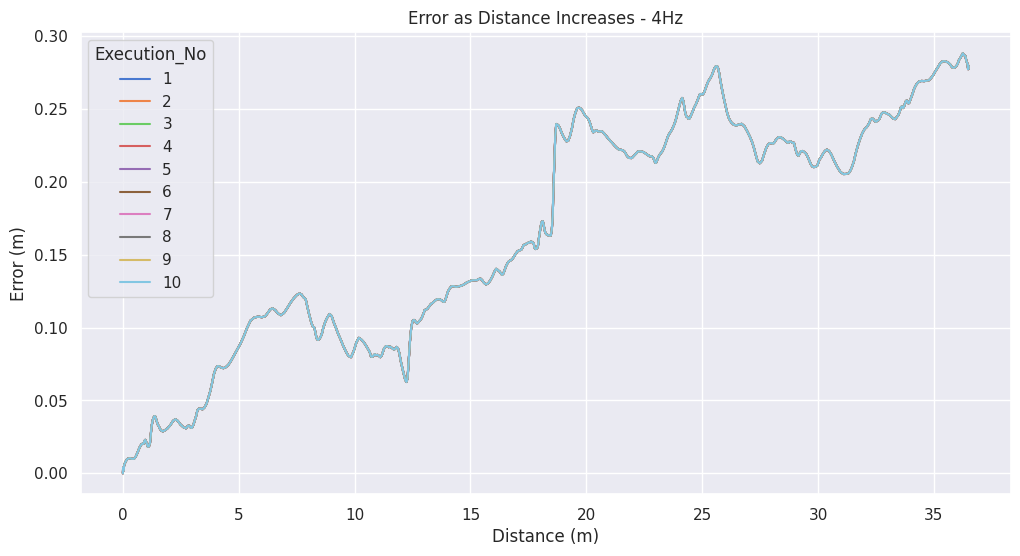

In [20]:
sns.set_theme(rc={'figure.figsize':(12, 6)})

title = 'Error as Distance Increases - 4Hz'

g = sns.lineplot(data = error_distance_dfs, x='Distance (m)', y = 'Error (m)', hue='Execution_No', legend='full', palette='muted')
g.set_title(title)

## Results Investigation After Performing Manipulations to IMU/CAM Timestamps

In [246]:
base_dir = '/home/shiva/Datasets/V2_01_easy/V2_01_easy/Kimera_VIO_Output'
working_dir = '10_Runs_New_Kimera_Frame_Drops_6Hz_Frame'

In [247]:
execution_folder_names = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']

In [248]:
dfs = []

for index, execution_folder_name in enumerate(execution_folder_names):
    df = pd.read_csv(f'{base_dir}/{working_dir}/{execution_folder_name}/traj_vio.csv')
    df['Execution_No'] = index + 10
    df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)
    dfs.append(df)

In [249]:
gt_df = pd.read_csv(f'{base_dir}/{working_dir}/{execution_folder_names[0]}/traj_gt.csv')
gt_df['Execution_No'] = 'GT'
gt_df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)
dfs.append(gt_df)

In [250]:
all_executions = pd.concat(dfs)

In [251]:
all_executions

,timestamp,x,y,z,qw,qx,qy,qz,vx,vy,vz,bgx,bgy,bgz,bax,bay,baz,Execution_No
0,1413393214805760512,-1.07920100000000007689,0.49198700000000000765,1.32931700000000008188,0.60602251493983294584,-0.00643099453555270005,-0.79536432417507574311,0.00947999194480480048,0.00408700000000000035,-0.00058299999999990000,0.00054100000000000003,-0.00229500000000000016,0.02493899999999989875,0.08166700000000000348,-0.02359999999999989884,0.12104299999999990067,0.07479199999999990023,10
1,1413393215005760512,-1.07874636595799100469,0.49183002497770478278,1.32987666111134994473,0.60593349623740688781,-0.00654317982950790040,-0.79542993622515367758,0.00947495263627930011,0.00031879437376760000,0.00007898170564357709,0.00636951588502500041,-0.00232476673281839996,0.02490010694481820108,0.08169984413217740160,-0.01140109554802969972,0.12077869097456089831,0.07070892796466320129,10
2,1413393215455760384,-1.07848272586129323436,0.49188217251477311942,1.33001159118033562834,0.60546673063727984854,-0.00646145616060739975,-0.79578450880557960456,0.00948245733653309969,0.00029517730697610001,0.00283464196021600019,0.00195419439032360007,-0.00230851160797089982,0.02379001304476149881,0.08234334439497509317,0.00179205132575869998,0.12048238000171500317,0.06693933380019230495,10
3,1413393215655760384,-1.07866926462678569543,0.49197864407757141425,1.32991419228658314111,0.60506819889812546442,-0.00678515161483219959,-0.79608138577029374794,0.00965986503111910047,0.00007994243273295737,0.00303928296776089998,0.00047092035000010003,-0.00215667037882270006,0.02374199979235850147,0.08244343386877220348,0.00210385157372280007,0.12084179076518360152,0.06681769993929109752,10
4,1413393215855760384,-1.07748596958848508187,0.49242985510515058234,1.33042420535366390233,0.60323794436682320885,-0.00660759772899230033,-0.79746977896415838227,0.00961804695851120085,0.00836848781528379965,0.00363978761315550013,0.00556509955075519969,-0.00238241765448519993,0.02367818308976669950,0.08297083062463900260,-0.01544117509896049921,0.12020604566696049820,0.06789613932901389370,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22396,1413393325460760576,-2.90823600000000004329,-0.45048399999999999554,0.95496599999999998154,0.47011700000000000710,-0.48787099999999999911,-0.64120299999999996743,-0.36031900000000000039,-0.00445800000000000016,-0.00077899999999999996,0.00286799999999999989,-0.00227500000000000011,0.02488299999999999887,0.08157699999999999674,-0.01963499999999999968,0.12354199999999999904,0.07849000000000000421,GT
22397,1413393325465760512,-2.90826099999999998502,-0.45048899999999997279,0.95498099999999996879,0.47012399999999998634,-0.48787399999999997435,-0.64119499999999995943,-0.36032100000000000239,-0.00572899999999999972,-0.00088599999999999996,0.00327800000000000010,-0.00227500000000000011,0.02488299999999999887,0.08157699999999999674,-0.01963499999999999968,0.12354199999999999904,0.07849000000000000421,GT
22398,1413393325470760704,-2.90829100000000018156,-0.45049299999999997679,0.95499900000000004230,0.47014099999999997559,-0.48786499999999999311,-0.64119300000000001294,-0.36031400000000002315,-0.00596100000000000015,-0.00083600000000000005,0.00370799999999999992,-0.00227500000000000011,0.02488299999999999887,0.08157699999999999674,-0.01963499999999999968,0.12354199999999999904,0.07849000000000000421,GT
22399,1413393325475760384,-2.90831900000000009854,-0.45049699999999998079,0.95501800000000003354,0.47015800000000002035,-0.48785299999999998111,-0.64119499999999995943,-0.36030400000000001315,-0.00546899999999999990,-0.00064099999999999997,0.00404899999999999965,-0.00227500000000000011,0.02488299999999999887,0.08157699999999999674,-0.01963499999999999968,0.12354199999999999904,0.07849000000000000421,GT


<Axes: xlabel='timestamp', ylabel='x'>

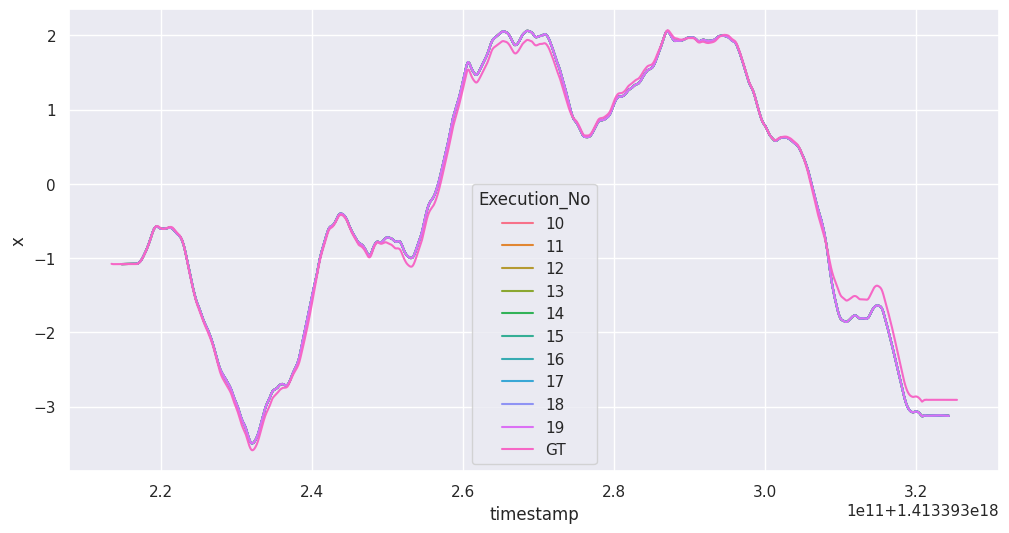

In [252]:
sns.lineplot(data=all_executions, x='timestamp', y='x', hue='Execution_No')

<Axes: xlabel='timestamp', ylabel='y'>

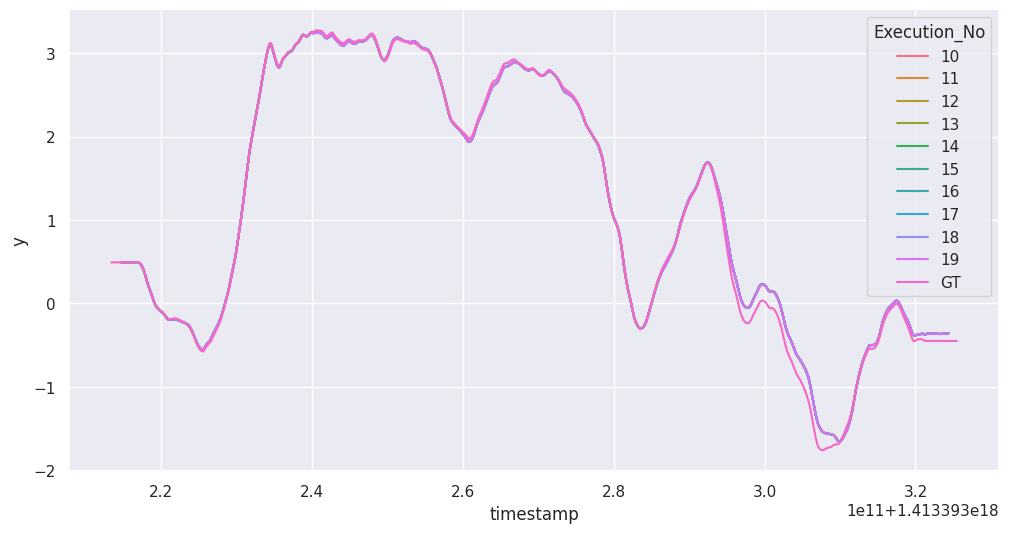

In [253]:
sns.lineplot(data=all_executions, x='timestamp', y='y', hue='Execution_No')

<Axes: xlabel='timestamp', ylabel='z'>

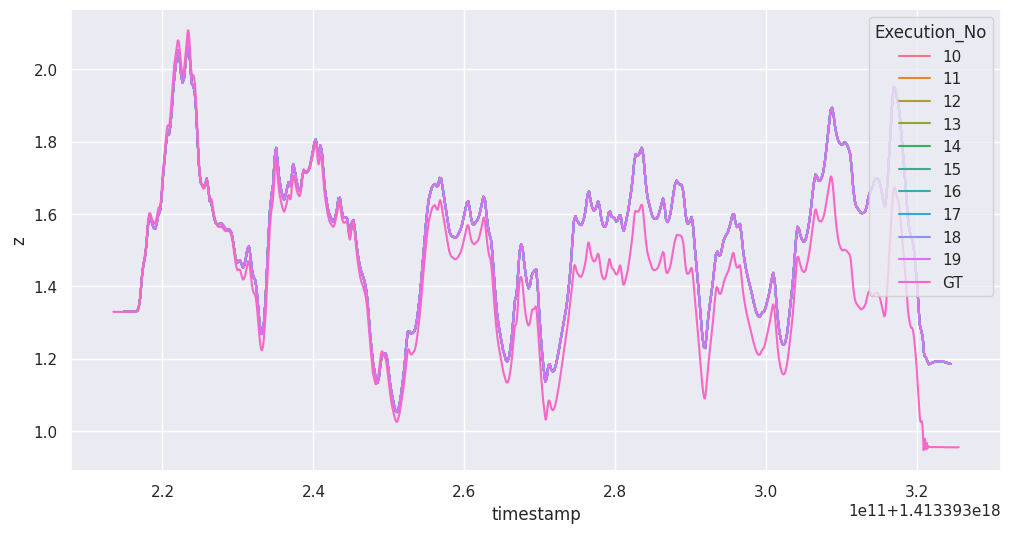

In [254]:
sns.lineplot(data=all_executions, x='timestamp', y='z', hue='Execution_No')

In [255]:
sns.set_theme(rc={'figure.figsize':(12,10)})

values = {}
for i in range(0,10):
    error_df = generate_error_gt_vio_pose(gt_df, dfs[i], DEBUG=False, SHOW_GRAPHS=False)
    values[i] = {'gt_x':error_df.iloc[-1]['gt_pos'][0],
                'gt_y':error_df.iloc[-1]['gt_pos'][1],
                'gt_z':error_df.iloc[-1]['gt_pos'][2],
                'vio_x': error_df.iloc[-1]['vio_pos'][0],
                'vio_y': error_df.iloc[-1]['vio_pos'][1],
                'vio_z': error_df.iloc[-1]['vio_pos'][2],
                'distance': error_df['distance'],
                'error': error_df['error']
                }

# df_comparison = pd.DataFrame(values).T
# df_comparison.reset_index(inplace=True)

# df_comparison_x_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_x', 'vio_x'])
# df_comparison_y_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_y', 'vio_y'])
# df_comparison_z_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_z', 'vio_z'])

540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540
540
Exiting loop because next vio index i: 540


In [256]:
error_distance_dfs = []

for i in range(0, 10):
    df = pd.DataFrame(data={'Distance (m)': values[i]['distance'], 'Error (m)':values[i]['error'], 'Execution_No':i+1})
    error_distance_dfs.append(df)

error_distance_dfs = pd.concat(error_distance_dfs)

Text(0.5, 1.0, 'Error as Distance Increases - 6Hz w/ Frame Drops')

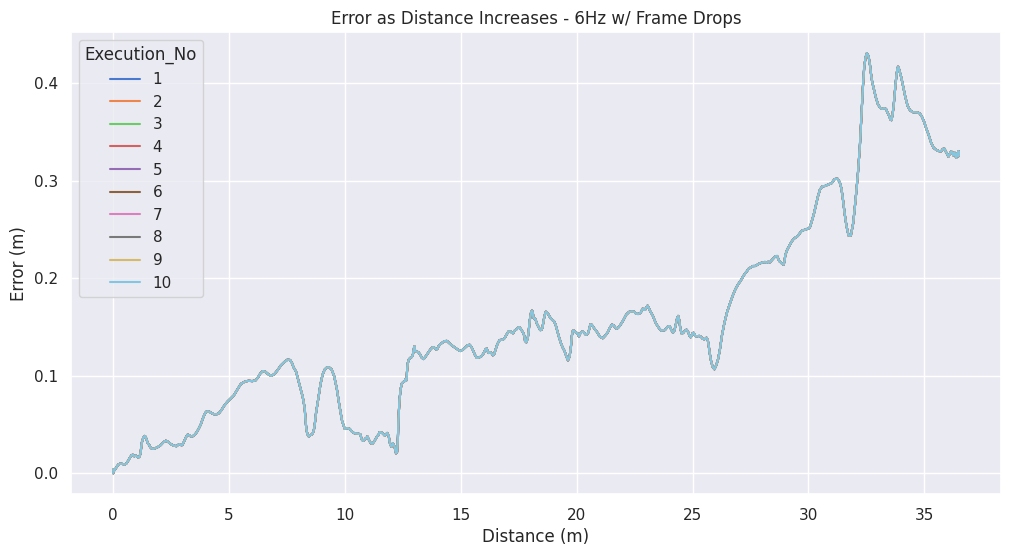

In [257]:
sns.set_theme(rc={'figure.figsize':(12, 6)})

title = 'Error as Distance Increases - 6Hz w/ Frame Drops'

g = sns.lineplot(data = error_distance_dfs, x='Distance (m)', y = 'Error (m)', hue='Execution_No', legend='full', palette='muted')
g.set_title(title)